In [59]:
import numpy as np
import matplotlib.pyplot as plt

flagMioC = 1
flagMioM = 1
flagClau = 0

def alphaRead(nome_file):
    reale = np.genfromtxt(nome_file+'a.csv', delimiter=',')[:,:-1]
    immaginario = np.genfromtxt(nome_file+'b.csv', delimiter=',')[:,:-1]
    return reale + 1j * immaginario

def legacyAvtLogRead(nome_file):
    return np.genfromtxt(nome_file, delimiter=';')

path = 'C:/Users/Mattia Mencagli/Documents/kcf/TRACKER/results/Trasposizione/'
pathMioC = path + 'alphas_C/'
pathMioM = path + 'alphas_MAT/'
pathClau = path + 'fromClau/Type2_256/'

R = 5
MioC = []
MioM = []
Clau = []
for i in range(R):
    if flagMioC : MioC.append(alphaRead(pathMioC+str(i)))
    if flagMioM : MioM.append(alphaRead(pathMioM+str(i)))

if flagClau : 
    ClauInfo = legacyAvtLogRead(pathClau+'legacyAvtLog.txt');
    # trova il ptimo track e inizia a prendere alpha dal passo prima, che conteneva l'ultima acquisition
    offsetR = np.where(ClauInfo[:,0] == 2)[0][0] - 1;     
    for i in range(R):
        Clau.append(alphaRead(pathClau+'alphaf/'+str(i+offsetR)))

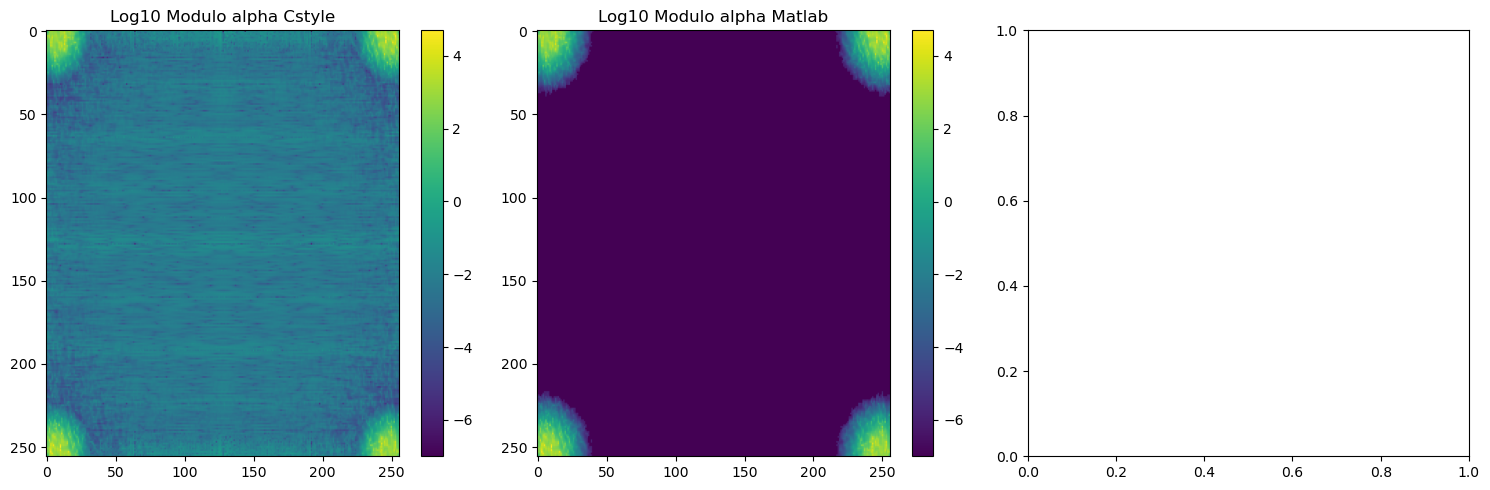

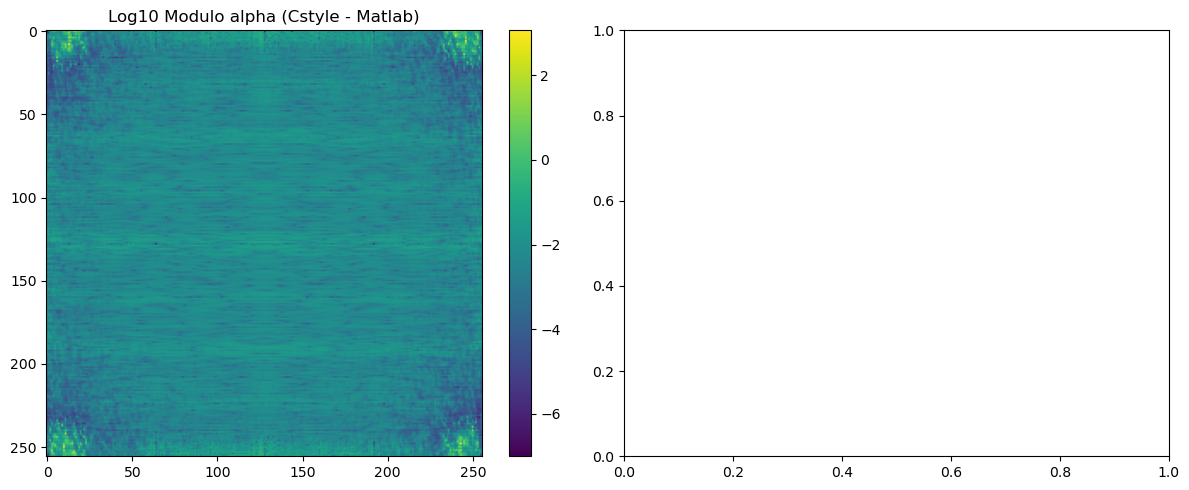

In [63]:
idx = 4

log10ground = 1e-7

# fig0, axs0 = plt.subplots(1, 3, figsize=(15, 5))
fig = plt.figure(0, figsize=[15, 5])
gs  = fig.add_gridspec(1,3) #, hspace=0)
axs = gs.subplots()
if flagMioC :
    im1 = axs[0].imshow(np.log10(np.abs(MioC[idx])+log10ground), cmap='viridis', aspect='auto')
    axs[0].set_title('Log10 Modulo alpha Cstyle')
    fig.colorbar(im1, ax=axs[0])
if flagMioM :
    im2 = axs[1].imshow(np.log10(np.abs(MioM[idx])+log10ground), cmap='viridis', aspect='auto')
    axs[1].set_title('Log10 Modulo alpha Matlab')
    fig.colorbar(im2, ax=axs[1])
if flagClau:
    im3 = axs[2].imshow(np.log10(np.abs(Clau[idx])+log10ground), cmap='viridis', aspect='auto')
    axs[2].set_title('Log10 Modulo alpha Claudia')
    fig.colorbar(im3, ax=axs[2])
plt.tight_layout()
plt.show()

#fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig = plt.figure(1, figsize=[12, 5])
gs  = fig.add_gridspec(1,2) #, hspace=0)
axs = gs.subplots()
if flagMioC and flagMioM:
    im1 = axs[0].imshow(np.log10(np.abs(MioC[idx]-MioM[idx])+log10ground), cmap='viridis', aspect='auto')
    axs[0].set_title('Log10 Modulo alpha (Cstyle - Matlab)')
    fig.colorbar(im1, ax=axs[0])
if flagClau and flagMioM:
    im2 = axs[1].imshow(np.log10(np.abs(Clau[idx]-MioM[idx])+log10ground), cmap='viridis', aspect='auto')
    axs[1].set_title('Log10 Modulo alpha (Claudia - Matlab)')
    fig.colorbar(im2, ax=axs[1])
plt.tight_layout()
plt.show()